In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\Joshua Naik\Desktop\PYTHON\Diwali Sales Data.csv", encoding='unicode_escape')
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [7]:
df.shape

(11251, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [9]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [10]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [12]:
df['State'].nunique()

16

In [13]:
df['Product_Category'].unique()

array(['Auto', 'Hand & Power Tools', 'Stationery', 'Tupperware',
       'Footwear & Shoes', 'Furniture', 'Food', 'Games & Toys',
       'Sports Products', 'Books', 'Electronics & Gadgets', 'Decor',
       'Clothing & Apparel', 'Beauty', 'Household items', 'Pet Care',
       'Veterinary', 'Office'], dtype=object)

In [14]:
df.drop(['Status','unnamed1'], axis=1, inplace=True)

In [15]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [17]:
df['Amount'] = df['Amount'].fillna(0).astype(int)

In [18]:
df.dropna(inplace=True)

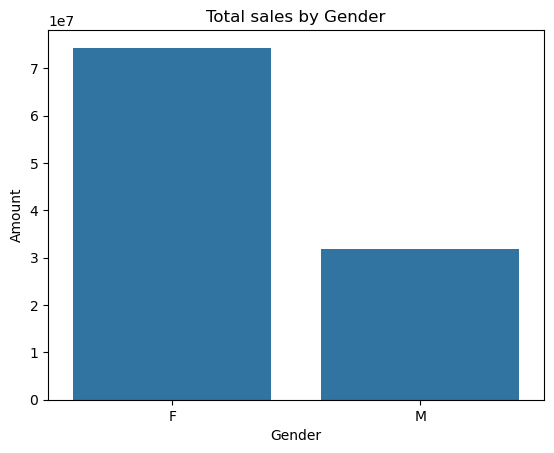

In [20]:
gender_sales = df.groupby('Gender')['Amount'].sum().reset_index()
sns.barplot(x='Gender', y='Amount', data=gender_sales)
plt.title("Total sales by Gender")
plt.show()

In [21]:
age_sales = df.groupby('Age Group')['Amount'].sum().reset_index()
age_sales

,Age Group,Amount
0,0-17,2699653
1,18-25,17240732
2,26-35,42613442
3,36-45,22144994
4,46-50,9207844
5,51-55,8261477
6,55+,4080987


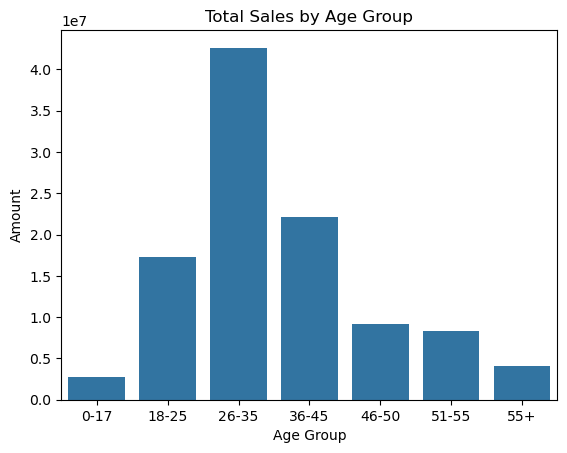

In [22]:
sns.barplot(x='Age Group', y='Amount', data=age_sales)

plt.title("Total Sales by Age Group")
plt.show()

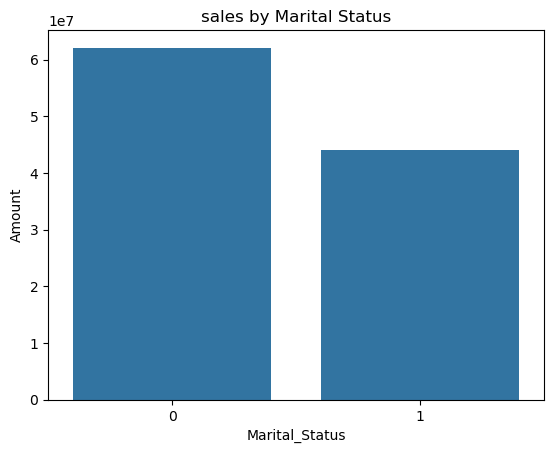

In [23]:
marital_sales = df.groupby('Marital_Status')['Amount'].sum().reset_index()
sns.barplot(x='Marital_Status', y='Amount', data=marital_sales)
plt.title("sales by Marital Status")
plt.show()

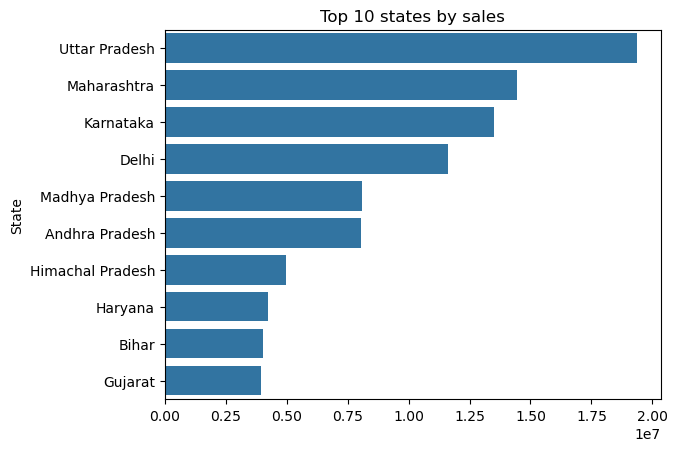

In [25]:
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=state_sales.values, y=state_sales.index)
plt.title("Top 10 states by sales")
plt.show()

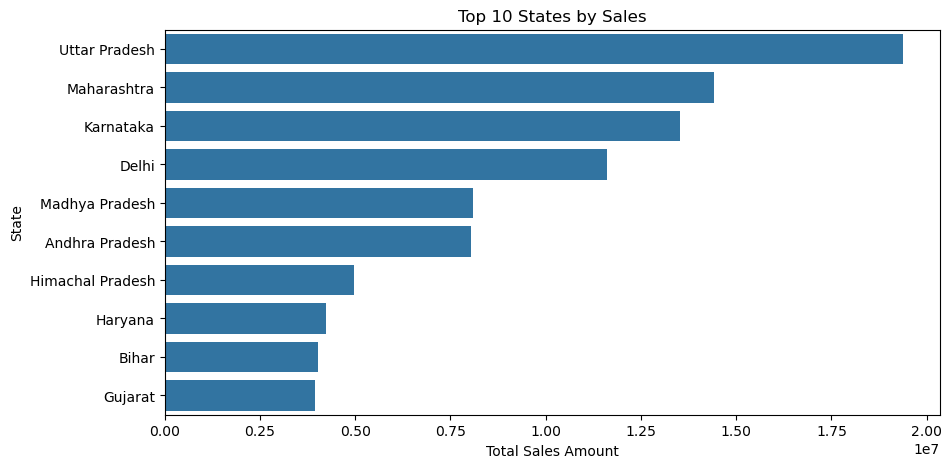

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(x=state_sales.values, y=state_sales.index)
plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales Amount")
plt.ylabel("State")
plt.show()

In [27]:
zone_sales = df.groupby('Zone')['Amount'].sum().sort_values(ascending=False)
zone_sales

Zone
Central     41600872
Southern    26606667
Western     18373625
Northern    12618752
Eastern      7049213
Name: Amount, dtype: int64

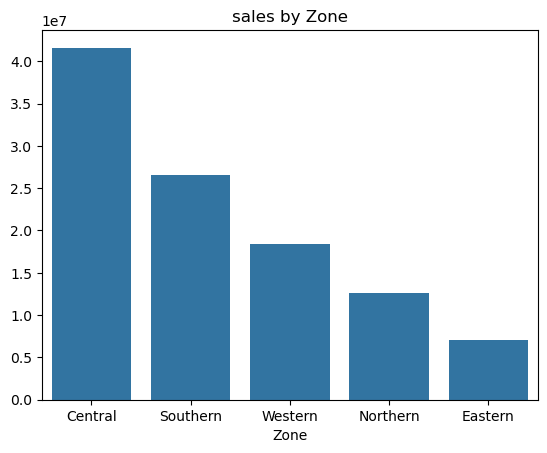

In [28]:
sns.barplot(x=zone_sales.index, y=zone_sales.values)
plt.title("sales by Zone")
plt.show()

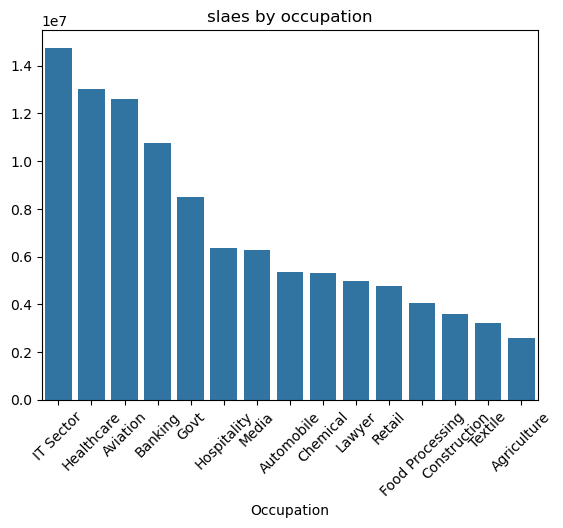

In [29]:
occupation_sales = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False)
sns.barplot(x=occupation_sales.index, y=occupation_sales.values)
plt.xticks(rotation=45)
plt.title("slaes by occupation")
plt.show()


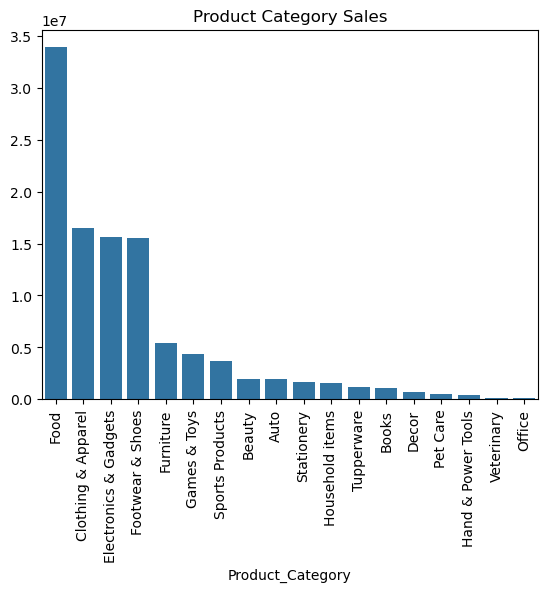

In [31]:
product_sales = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)
sns.barplot(x=product_sales.index, y=product_sales.values)
plt.xticks(rotation=90)
plt.title("Product Category Sales")
plt.show()

In [33]:
top_customers = df.groupby('Cust_name')['Amount'].sum().sort_values(ascending=False).head(20)
top_customers

Cust_name
Vishakha     382782
Sudevi       287142
Vasudev      281034
Neola        275234
Alejandro    272517
Aastha       266961
Shreyshi     265603
Hazel        242343
Akshat       241349
Gopal        239147
Halladay     226521
Parth        222002
Lalita       220435
Siddharth    219481
Barton       219321
Cathy        217238
Akash        215508
Sukant       214455
Sanjay       212217
Becky        211562
Name: Amount, dtype: int64

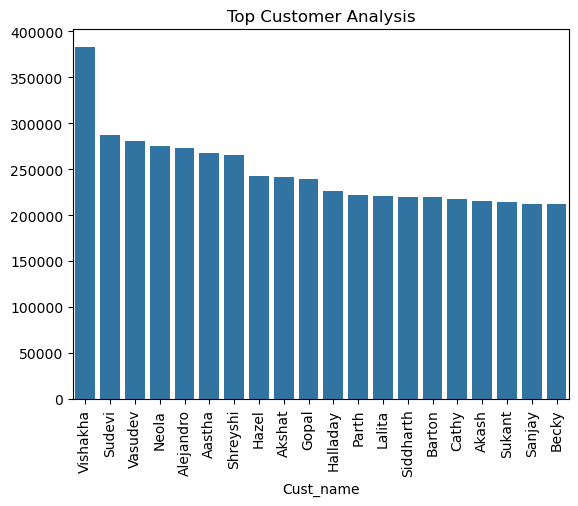

In [35]:
sns.barplot(x=top_customers.index, y=top_customers.values)
plt.xticks(rotation=90)
plt.title("Top Customer Analysis")
plt.show()

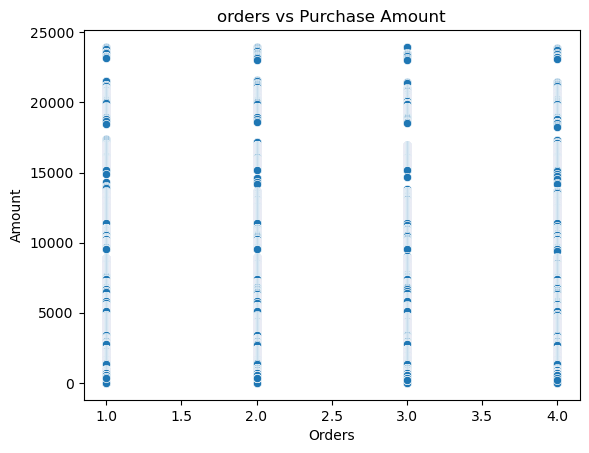

In [36]:
sns.scatterplot(x='Orders', y='Amount', data=df)
plt.title("orders vs Purchase Amount")
plt.show()

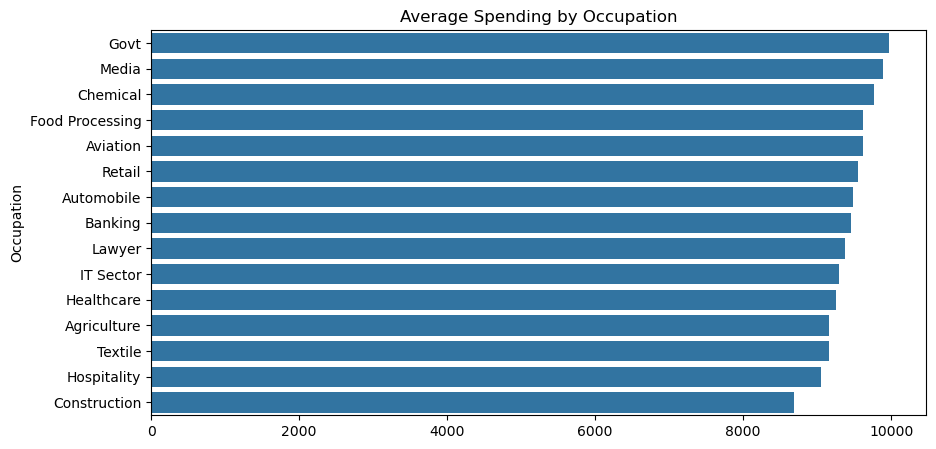

In [37]:
occupation_avg = df.groupby('Occupation')['Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=occupation_avg.values, y=occupation_avg.index)

plt.title("Average Spending by Occupation")
plt.show()

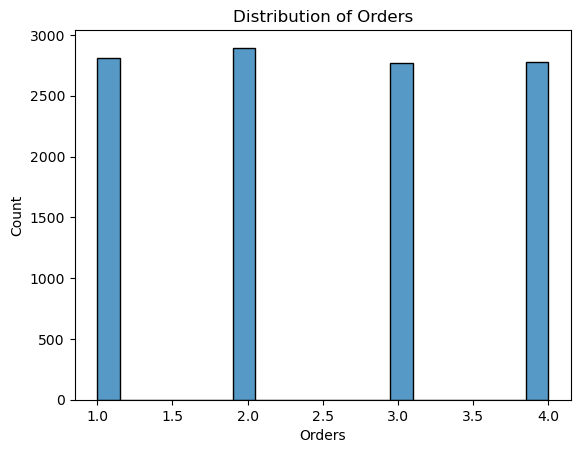

In [38]:
sns.histplot(df['Orders'], bins=20)

plt.title("Distribution of Orders")
plt.show()

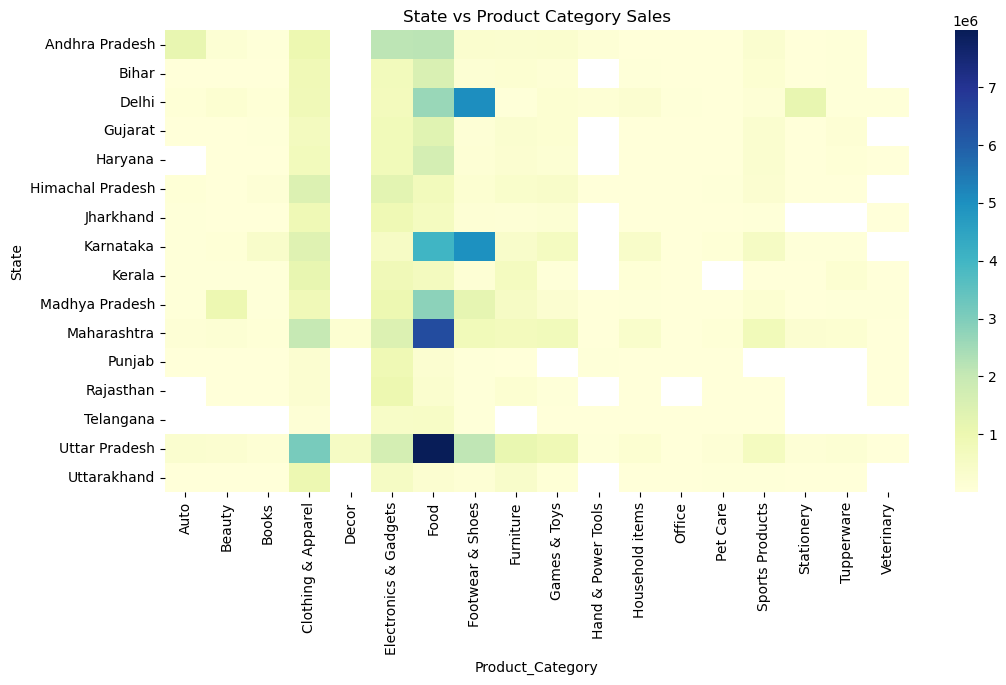

In [39]:
state_product = pd.pivot_table(df, values='Amount', index='State', columns='Product_Category', aggfunc='sum')

plt.figure(figsize=(12,6))
sns.heatmap(state_product, cmap='YlGnBu')

plt.title("State vs Product Category Sales")
plt.show()

In [40]:
"""
Key Business Insights

1. Female customers contribute the highest share of Diwali sales.
2. Customers aged 26–35 years are the most active buyers.
3. Certain states generate significantly higher festive sales.
4. Married customers tend to spend more compared to single customers.
5. IT and healthcare professionals show strong purchasing power.
6. Clothing, food, and electronics are among the best-selling product categories.
"""

'\nKey Business Insights\n\n1. Female customers contribute the highest share of Diwali sales.\n2. Customers aged 26–35 years are the most active buyers.\n3. Certain states generate significantly higher festive sales.\n4. Married customers tend to spend more compared to single customers.\n5. IT and healthcare professionals show strong purchasing power.\n6. Clothing, food, and electronics are among the best-selling product categories.\n'

In [41]:
"""
Business Recommendations

1. Target female customers with personalized festive offers.
2. Focus advertising on the 26–35 age group.
3. Increase marketing campaigns in high-performing states and zones.
4. Provide bundle offers on top product categories.
5. Develop loyalty programs for frequent customers.
"""

'\nBusiness Recommendations\n\n1. Target female customers with personalized festive offers.\n2. Focus advertising on the 26–35 age group.\n3. Increase marketing campaigns in high-performing states and zones.\n4. Provide bundle offers on top product categories.\n5. Develop loyalty programs for frequent customers.\n'